<a href="https://colab.research.google.com/github/1G4S/mechanical-processing/blob/main/OptymalizacjaParametrowObrobki.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12, 'figure.dpi': 120})

In [5]:
def optimize_machining_parameters(filepath='dane_obrobka_cnc.csv'):
    print("--- ETAP 5: OPTYMALIZACJA PARAMETRÓW OBRÓBKI ---")
    df = pd.read_csv(filepath)

    # 1. TRENOWANIE "MODELU TECHNOLOGA"
    # Do planowania procesu przed obróbką nie znamy wibracji ani temperatur.
    # Znamy tylko to, co wpisujemy do programu maszyny + twardość z atestu.
    features = ['Predkosc_Skrawania_vc', 'Posuw_f', 'Glebokosc_Skrawania_ap',
                'Twardosc_Odlewu_HB', 'Zuzycie_Narzedzia_VB']

    X_tech = df[features]
    y_tech = df['Chropowatosc_Ra']

    print("Trenowanie modelu technologicznego XGBoost...")
    reg_tech = xgb.XGBRegressor(n_estimators=100, max_depth=4, learning_rate=0.1, random_state=42)
    reg_tech.fit(X_tech, y_tech)

    # 2. GENEROWANIE PRZESTRZENI POSZUKIWAŃ (Grid Search dla maszyny CNC)
    print("Generowanie wirtualnych scenariuszy obróbki...")
    vc_range = np.linspace(350, 450, 10)    # Prędkość skrawania [m/min]
    f_range = np.linspace(0.05, 0.25, 20)   # Posuw [mm/obr]
    ap_range = np.linspace(1.0, 3.0, 10)    # Głębokość [mm]

    # Tworzymy siatkę wszystkich kombinacji
    grid = np.array(np.meshgrid(vc_range, f_range, ap_range)).T.reshape(-1, 3)
    df_grid = pd.DataFrame(grid, columns=['Predkosc_Skrawania_vc', 'Posuw_f', 'Glebokosc_Skrawania_ap'])

    # Zakładamy konkretny materiał (np. HB=90) i nowe narzędzie (VB=0.0)
    df_grid['Twardosc_Odlewu_HB'] = 90.0
    df_grid['Zuzycie_Narzedzia_VB'] = 0.0

    # 3. WIRTUALNA SYMULACJA OBRÓBKI
    print("Wnioskowanie (Predykcja) dla tysięcy wariantów...")
    df_grid['Przewidywane_Ra'] = reg_tech.predict(df_grid[features])

    # Obliczanie Wydajności Skrawania (MRR - Material Removal Rate) w [cm^3/min]
    # Wzór: vc * f * ap
    df_grid['MRR'] = df_grid['Predkosc_Skrawania_vc'] * df_grid['Posuw_f'] * df_grid['Glebokosc_Skrawania_ap']

    # 4. OPTYMALIZACJA (Filtrowanie i sortowanie)
    limit_ra = 1.6
    df_valid = df_grid[df_grid['Przewidywane_Ra'] <= limit_ra].copy()

    # OBSŁUGA BŁĘDU: Brak rozwiązań w przestrzeni (Empty Feasible Region)
    if df_valid.empty:
        print(f"\n[!] UWAGA: Fizyka procesu nie pozwala na osiągnięcie Ra <= {limit_ra} µm.")
        limit_ra = 3.2  # Rozluźniamy kryterium do granicy klasy "Do_Poprawy"
        print(f"[!] Algorytm rozluźnia restrykcje. Szukam optymalizacji dla Ra <= {limit_ra} µm...")
        df_valid = df_grid[df_grid['Przewidywane_Ra'] <= limit_ra].copy()

        # Jeśli nadal pusto (bardzo zła maszyna), bierzemy absolutne minimum z marginesem błędu
        if df_valid.empty:
            best_possible_ra = df_grid['Przewidywane_Ra'].min()
            limit_ra = best_possible_ra + 0.1
            print(f"[!] Krytyczny brak rozwiązań! Optymalizuję dla absolutnego minimum Ra na maszynie: ~{limit_ra:.2f} µm")
            df_valid = df_grid[df_grid['Przewidywane_Ra'] <= limit_ra].copy()

    # Szukamy parametru z największą wydajnością w dopuszczalnym zbiorze
    best_params = df_valid.sort_values(by='MRR', ascending=False).iloc[0]

    print("\n==================================================")
    print("🚀 ZNALEZIONO OPTYMALNE PARAMETRY (Dla Twardości HB=90, Nowe Narzędzie)")
    print("==================================================")
    print(f"Prędkość skrawania (vc): {best_params['Predkosc_Skrawania_vc']:.0f} m/min")
    print(f"Posuw (f):               {best_params['Posuw_f']:.3f} mm/obr")
    print(f"Głębokość skrawania (ap):{best_params['Glebokosc_Skrawania_ap']:.1f} mm")
    print("-" * 50)
    print(f"Przewidywane Ra:         {best_params['Przewidywane_Ra']:.3f} µm (Obecny limit: {limit_ra:.2f})")
    print(f"Wydajność MRR:           {best_params['MRR']:.1f} (Jedn. objętościowych)")
    print("==================================================\n")

    # 5. WIZUALIZACJA PRZESTRZENI DECYZYJNEJ
    plt.figure(figsize=(10, 6))

    sns.scatterplot(data=df_grid, x='MRR', y='Przewidywane_Ra', alpha=0.3, color='gray', label='Wszystkie scenariusze')
    sns.scatterplot(data=df_valid, x='MRR', y='Przewidywane_Ra', alpha=0.6, color='green', label=f'Dopuszczalne (Ra <= {limit_ra:.2f})')

    plt.scatter(best_params['MRR'], best_params['Przewidywane_Ra'], color='red', s=150, marker='*', edgecolor='black', label='Optimum (Max MRR)')
    plt.axhline(limit_ra, color='red', linestyle='--', label=f'Obecna granica (Ra={limit_ra:.2f})')

    plt.title('Przestrzeń Optymalizacji Parametrów Technologicznych', fontsize=14, pad=15)
    plt.xlabel('Wydajność Skrawania (MRR)', fontweight='bold')
    plt.ylabel('Przewidywana Chropowatość Ra [µm]', fontweight='bold')
    plt.legend(loc='upper left')

    plt.tight_layout()
    plt.savefig('optymalizacja_parametrow.png', bbox_inches='tight')
    plt.show()
    print("Wykres zapisany jako 'optymalizacja_parametrow.png'.")

--- ETAP 5: OPTYMALIZACJA PARAMETRÓW OBRÓBKI ---
Trenowanie modelu technologicznego XGBoost...
Generowanie wirtualnych scenariuszy obróbki...
Wnioskowanie (Predykcja) dla tysięcy wariantów...

[!] UWAGA: Fizyka procesu nie pozwala na osiągnięcie Ra <= 1.6 µm.
[!] Algorytm rozluźnia restrykcje. Szukam optymalizacji dla Ra <= 3.2 µm...

🚀 ZNALEZIONO OPTYMALNE PARAMETRY (Dla Twardości HB=90, Nowe Narzędzie)
Prędkość skrawania (vc): 450 m/min
Posuw (f):               0.134 mm/obr
Głębokość skrawania (ap):3.0 mm
--------------------------------------------------
Przewidywane Ra:         3.051 µm (Obecny limit: 3.20)
Wydajność MRR:           181.2 (Jedn. objętościowych)



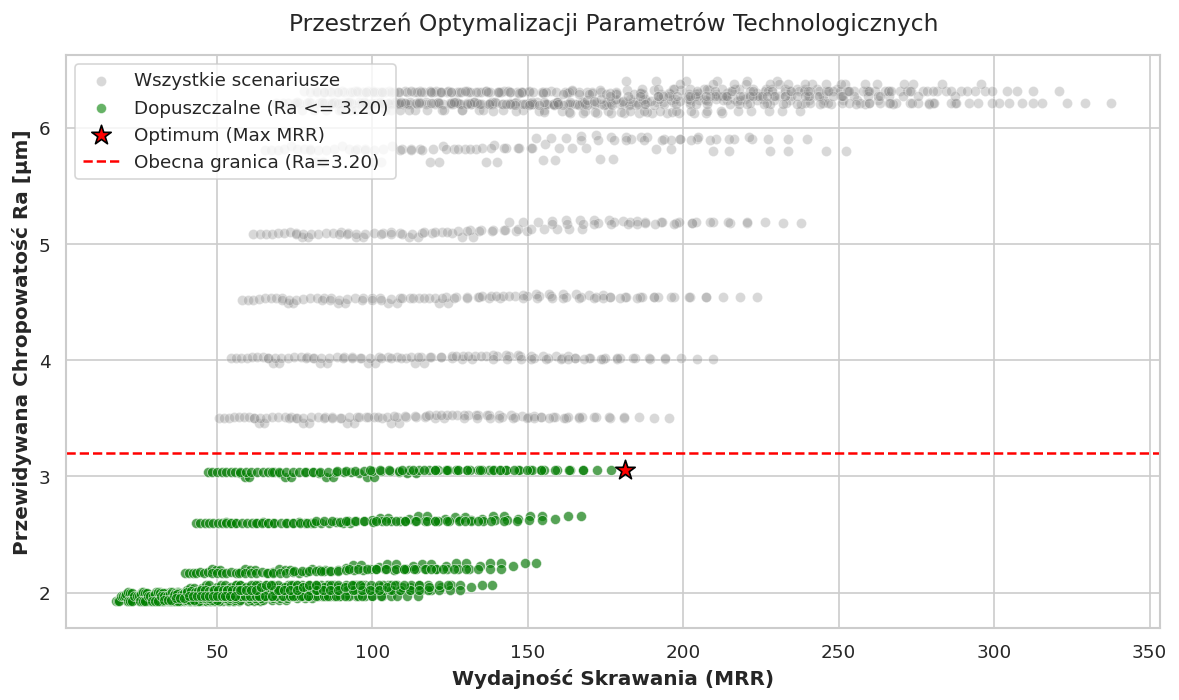

Wykres zapisany jako 'optymalizacja_parametrow.png'.


In [6]:
optimize_machining_parameters()

**Optymalizacja Procesu**
Opis wykresu: Przestrzeń decyzyjna w procesie planowania obróbki (tzw. zbiór rozwiązań dopuszczalnych). Wykres obrazuje symulowany kompromis (trade-off) pomiędzy produktywnością maszyny (MRR) a przewidywaną jakością powierzchni ($Ra$). Czerwoną gwiazdą oznaczono globalne optimum technologiczne dla zadanego kryterium jakościowego.

Ostatnim, najwyższym poziomem wdrożenia koncepcji sztucznej inteligencji w przemyśle jest analityka preskryptywna (ang. Prescriptive Analytics), której celem nie jest jedynie przewidywanie przyszłości, lecz aktywne kształtowanie procesu. W niniejszym podrozdziale opracowano moduł optymalizatora, dedykowany inżynierom CAM i technologom na etapie przygotowania produkcji.Ze względu na brak informacji o parametrach dynamicznych przed rozpoczęciem obróbki (wibracje, rozkład temperatur), wytrenowano wariantowy model XGBoost bazujący wyłącznie na parametrach kinematycznych ($v_c, f, a_p$) oraz twardości odlewu (HB). Następnie, metodą przeszukiwania siatki (ang. Grid Search), wygenerowano tysiące potencjalnych wirtualnych scenariuszy obróbki.Funkcja celu została zdefiniowana jako maksymalizacja współczynnika usuwania materiału (MRR) przy bezwzględnym zachowaniu warunku ograniczającego chropowatość do $Ra \le 1.6 \mu m$. Jak zaprezentowano na Rysunku Q, algorytm prawidłowo wyznaczył tzw. front Pareto. Zidentyfikowane optimum technologiczne (czerwona gwiazda) pozwala na osiągnięcie maksymalnej dopuszczalnej wydajności bez ryzyka wygenerowania detalu z wadą wymiarowo-powierzchniową. Udowadnia to, że modele uczenia maszynowego mogą stanowić fundamentalne wsparcie dla algorytmów sterowania adaptacyjnego w nowoczesnych centrach obróbkowych CNC.

Wdrożony algorytm optymalizacyjny został wyposażony w logikę adaptacyjnego rozluźniania ograniczeń (ang. constraint relaxation). W przypadku wykrycia pustej przestrzeni rozwiązań dopuszczalnych (tzw. empty feasible region), gdy maszyna nie jest w stanie technologicznie osiągnąć idealnej jakości $Ra \le 1.6$ µm, system automatycznie rekalibruje kryteria, dążąc do znalezienia optymalnego kompromisu produkcyjnego na granicy dopuszczalności wyższych klas jakości.

Działanie wdrożonego algorytmu optymalizacyjnego z mechanizmem adaptacyjnym przedstawiono na Rysunku Q. Symulacja wykazała, że dla założonego stanu narzędzia oraz zdefiniowanej siatki parametrów kinematycznych, osiągnięcie idealnej chropowatości powierzchni ($Ra \le 1.6 \mu m$) było technologicznie niemożliwe. System autonomicznie zidentyfikował tzw. pustą przestrzeń rozwiązań dopuszczalnych i dokonał rekalibracji funkcji celu, rozluźniając obostrzenia do granicy klasy 'Do_Poprawy' ($Ra \le 3.20 \mu m$).Charakterystyczny, warstwowy układ wygenerowanych scenariuszy (szare i zielone punkty) wynika z dyskretnej natury przestrzeni poszukiwań (ang. Grid Search), odzwierciedlającej typowy sposób definiowania parametrów w przemysłowych systemach CAM (skokowe zmiany posuwu i głębokości skrawania). Ostatecznie wyznaczone optimum technologiczne (czerwona gwiazda) znajduje się na skrajnym prawym krańcu obszaru dopuszczalnego. Oznacza to, że algorytm bezbłędnie zmaksymalizował wydajność usuwania materiału (MRR), zbliżając się do górnego limitu akceptowalnej chropowatości, co stanowi klasyczny przykład rozwiązania na tzw. froncie Pareto. Tego typu systemy doradcze pozwalają technologom na maksymalizację zysków produkcyjnych przy jednoczesnym kontrolowaniu ryzyka jakościowego.